# Packages

In [2]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

In [5]:
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf

# Costs

In [3]:
# PyPSA Costs
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

# Weather Data

In [6]:
# Weather Data
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())
CF_solar = PV_data.mean(axis = 1) # average all the years
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets
CF_wind["2021"]


time
2021-01-01 00:00:00    0.088753
2021-01-01 01:00:00    0.080665
2021-01-01 02:00:00    0.071514
2021-01-01 03:00:00    0.061485
2021-01-01 04:00:00    0.052379
                         ...   
2021-12-31 19:00:00    0.267740
2021-12-31 20:00:00    0.269965
2021-12-31 21:00:00    0.280798
2021-12-31 22:00:00    0.309923
2021-12-31 23:00:00    0.334850
Length: 8760, dtype: float64

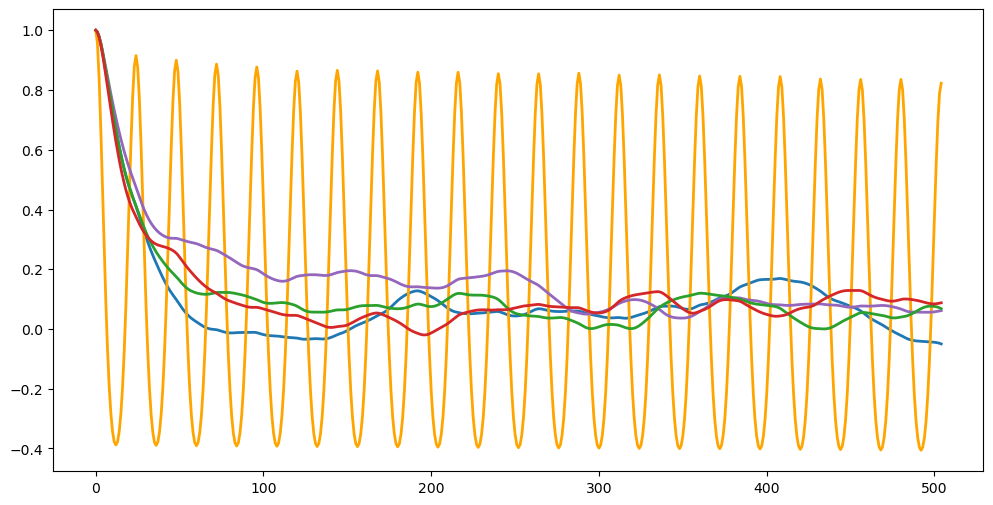

In [7]:

# 1. Calculate the ACF values for a week (168 hours)
nlags = 24*7*3
acf_wind21 = acf(CF_wind["2021"], nlags=nlags)
acf_solar21 = acf(CF_solar["2021"], nlags=nlags)
acf_wind22 = acf(CF_wind["2022"], nlags=nlags)
acf_wind23 = acf(CF_wind["2023"], nlags=nlags)
acf_wind24 = acf(CF_wind["2024"], nlags=nlags)
#acf_solar22 = acf(CF_solar["2022"], nlags=nlags)
# 2. Plot using plt.plot() for clarity over long durations
plt.figure(figsize=(12, 6))
# Plot wind in blue and solar in orange
plt.plot(range(len(acf_wind21)), acf_wind21, label='Wind ($CF_{wind}$) 2021', color='tab:blue', linewidth=2)
plt.plot(range(len(acf_solar21)), acf_solar21, label='Solar ($CF_{solar}$)', color='orange', linewidth=2)
plt.plot(range(len(acf_wind22)), acf_wind22, label='Wind ($CF_{wind}$) 2022', color='tab:purple', linewidth=2)
plt.plot(range(len(acf_wind23)), acf_wind23, label='Wind ($CF_{wind}$) 2023', color='tab:green', linewidth=2)
plt.plot(range(len(acf_wind24)), acf_wind24, label='Wind ($CF_{wind}$) 2024', color='tab:red', linewidth=2)
#plt.plot(range(len(acf_solar22)), acf_solar22, label='Solar ($CF_{solar}$)', color='red', linewidth=2)



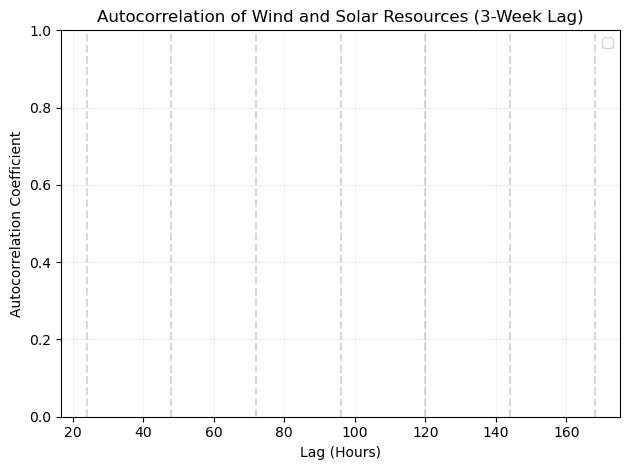

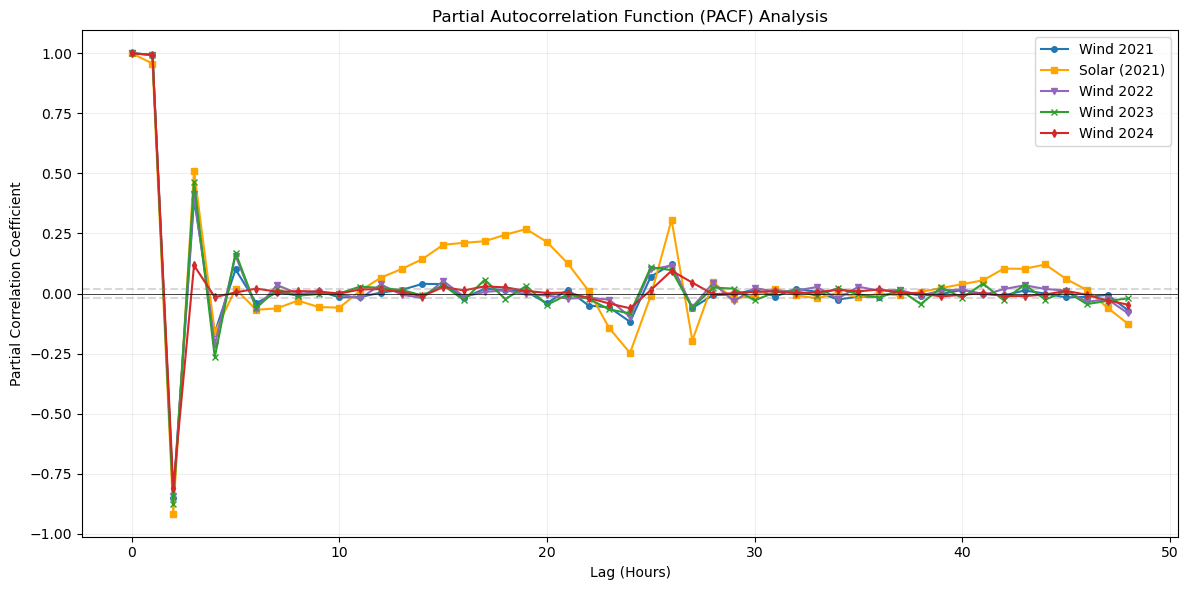

In [8]:

# 3. Add vertical dashed lines at 24-hour intervals to highlight the cycle
for day in range(1, 8):
    plt.axvline(x=day*24, color='gray', linestyle='--', alpha=0.3)

# Formatting for your thesis
plt.title("Autocorrelation of Wind and Solar Resources (3-Week Lag)")
plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation Coefficient")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 1. Calculate the PACF values (use 48h to see the AR order clearly)
nlags_pacf = 48
pacf_wind21 = pacf(CF_wind["2021"], nlags=nlags_pacf)
pacf_solar21 = pacf(CF_solar["2021"], nlags=nlags_pacf)
pacf_wind22 = pacf(CF_wind["2022"], nlags=nlags_pacf)
pacf_wind23 = pacf(CF_wind["2023"], nlags=nlags_pacf)
pacf_wind24 = pacf(CF_wind["2024"], nlags=nlags_pacf)

# 2. Plotting
plt.figure(figsize=(12, 6))
# Plot wind series and the solar comparison
plt.plot(range(len(pacf_wind21)), pacf_wind21, label='Wind 2021', color='tab:blue', marker='o', markersize=4)
plt.plot(range(len(pacf_solar21)), pacf_solar21, label='Solar (2021)', color='orange', marker='s', markersize=4)
plt.plot(range(len(pacf_wind22)), pacf_wind22, label='Wind 2022', color='tab:purple', marker='v', markersize=4)
plt.plot(range(len(pacf_wind23)), pacf_wind23, label='Wind 2023', color='tab:green', marker='x', markersize=4)
plt.plot(range(len(pacf_wind24)), pacf_wind24, label='Wind 2024', color='tab:red', marker='d', markersize=4)
# 3. Add confidence intervals (critical for PACF)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# Significance level approximately 1.96/sqrt(N)
plt.axhline(y=0.02, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=-0.02, color='gray', linestyle='--', alpha=0.3)
plt.title("Partial Autocorrelation Function (PACF) Analysis")
plt.xlabel("Lag (Hours)")
plt.ylabel("Partial Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# NG Prices

In [9]:
## NG Prices
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]
gas_price_data = pd.read_excel(gas_file)

# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 